# ***Ⅲ. 이미지 데이터 처리***
## ***02. 이미지 데이터의 변환***
- 행렬 데이터의 하나인 이미지에 행렬 연산을 통해 변환을 수행해봅니다
- 이미지의 밝기 변환, 두 이미지의 합성 등이 모두 행렬 연산을 통해 이루어집니다

### ***전치행렬 구하기***
- numpy 라이브러리에서는 편리하게 전치행렬을 구할수 있는 방법을 제공합니다

In [2]:
import numpy as np

A = np.array([[1, 2],
              [3, 4],
              [5, 6]])

print(A)
print()
print(A.T)

[[1 2]
 [3 4]
 [5 6]]

[[1 3 5]
 [2 4 6]]


### ***전치행렬을 이용한 이미지 구도 변경***

In [3]:
# imshow함수 준비
import cv2
from matplotlib import pyplot as plt

def cv2_imshow(img, title='Image', figsize=(5,5), axis='on'):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis(axis)
    plt.show()

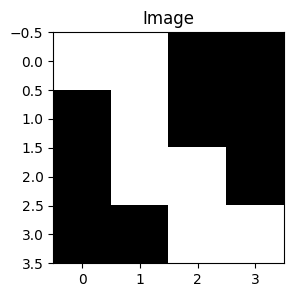

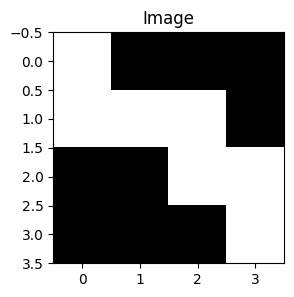

In [ ]:
A = np.array([[1, 1, 0, 0],
              [0, 1, 0, 0],
              [0, 1, 1, 0], 
              [0, 0, 1, 1]]).astype(np.uint8)
A = A * 255

cv2_imshow(A, figsize=(3,3))
cv2_imshow(A.T, figsize=(3,3))

## ***흑백 이미지의 합성***
- 두 행렬을 더하는 것입니다

In [9]:
A = np.array([[1, 4],
              [3, 6]]).astype(np.uint8)

B = np.array([[5, 1],
              [4, 1]]).astype(np.uint8)


A + B

array([[6, 5],
       [7, 7]], dtype=uint8)

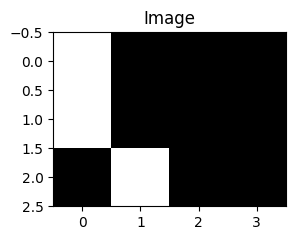

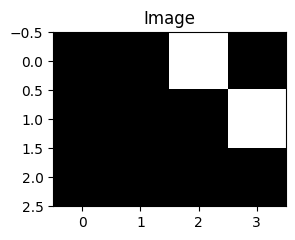

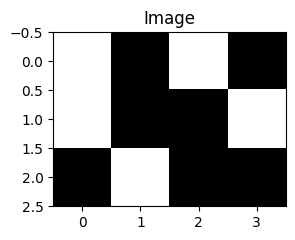

In [13]:
A = np.array([[1, 0, 0, 0],
              [1, 0, 0, 0],
              [0, 1, 0, 0]]).astype(np.uint8)

B = np.array([[0, 0, 1, 0],
              [0, 0, 0, 1],
              [0, 0, 0, 0]]).astype(np.uint8)

ret, A = cv2.threshold(A, 0, 255, cv2.THRESH_BINARY)
ret, B = cv2.threshold(B, 0, 255, cv2.THRESH_BINARY)
C = A + B

cv2_imshow(A, figsize=(3,3))
cv2_imshow(B, figsize=(3,3))
cv2_imshow(C, figsize=(3,3))

### ***픽셀에 농도가 있는 경우***
- modulo 연산
  - 100 + 280 = 280
  - 255보다 커졌습니다
  - 280 -> 한바퀸 돌아서 24가 됩니다

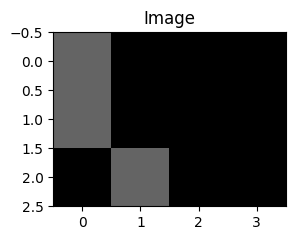

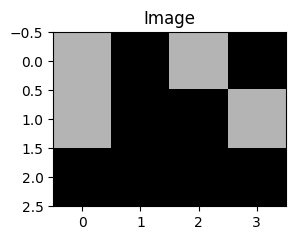

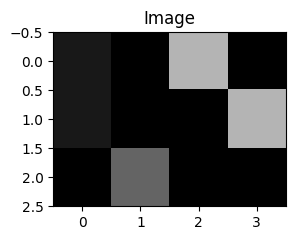

[[ 24   0 180   0]
 [ 24   0   0 180]
 [  0 100   0   0]]


In [ ]:
A = np.array([[100, 0, 0, 0],
              [100, 0, 0, 0],
              [0, 100, 0, 0]]).astype(np.uint8)

B = np.array([[180, 0, 180, 0],
              [180, 0, 0, 180],
              [0, 0, 0, 0]]).astype(np.uint8)
              
# Modulo 연산
C = A + B

cv2_imshow(A, figsize=(3,3))
cv2_imshow(B, figsize=(3,3))
cv2_imshow(C, figsize=(3,3))
print(C)

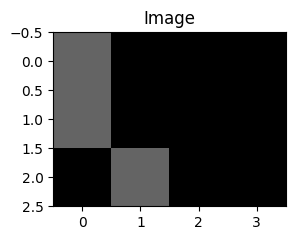

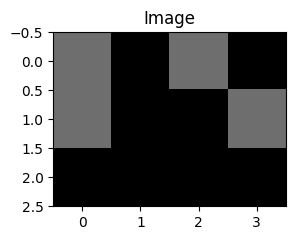

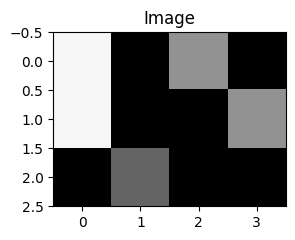

[[246   0 146   0]
 [246   0   0 146]
 [  0 100   0   0]]


In [22]:
A = np.array([[100, 0, 0, 0],
              [100, 0, 0, 0],
              [0, 100, 0, 0]]).astype(np.uint8)

B = np.array([[110, 0, 110, 0],
              [110, 0, 0, 110],
              [0, 0, 0, 0]]).astype(np.uint8)
              
# Modulo 연산
C = A - B

cv2_imshow(A, figsize=(3,3))
cv2_imshow(B, figsize=(3,3))
cv2_imshow(C, figsize=(3,3))
print(C)

- saturated 연산
  - 100 + 280 = 280
  - 255보다 커졌습니다
  - 255로 고정됩니다

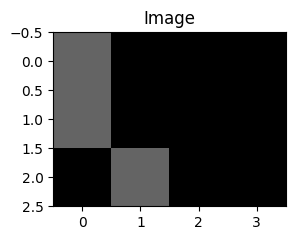

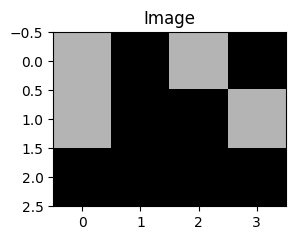

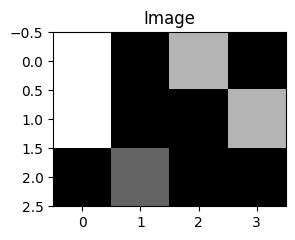

[[255   0 180   0]
 [255   0   0 180]
 [  0 100   0   0]]


In [21]:
A = np.array([[100, 0, 0, 0],
              [100, 0, 0, 0],
              [0, 100, 0, 0]]).astype(np.uint8)

B = np.array([[180, 0, 180, 0],
              [180, 0, 0, 180],
              [0, 0, 0, 0]]).astype(np.uint8)
              
# Saturated 연산
C = cv2.add(A, B)

cv2_imshow(A, figsize=(3,3))
cv2_imshow(B, figsize=(3,3))
cv2_imshow(C, figsize=(3,3))
print(C)

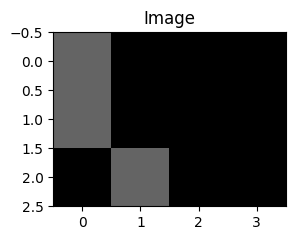

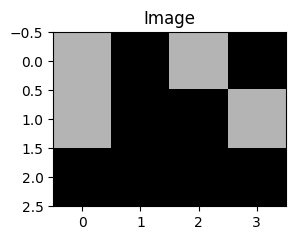

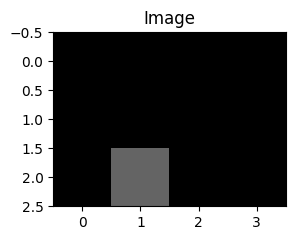

[[  0   0   0   0]
 [  0   0   0   0]
 [  0 100   0   0]]


In [23]:
A = np.array([[100, 0, 0, 0],
              [100, 0, 0, 0],
              [0, 100, 0, 0]]).astype(np.uint8)

B = np.array([[180, 0, 180, 0],
              [180, 0, 0, 180],
              [0, 0, 0, 0]]).astype(np.uint8)
              
# Saturated 연산
C = cv2.subtract(A, B)

cv2_imshow(A, figsize=(3,3))
cv2_imshow(B, figsize=(3,3))
cv2_imshow(C, figsize=(3,3))
print(C)

## ***이미지의 밝기 조절하기***
- 행렬에 k배 하는 것으로 밝기가 조절 됩니다(Contrast)
  - 이 때 픽셀간의 값 차이는 k만큼 벌어지게 됩니다
- 또한 b를 더하는 것으로도 밝기가 조절됩니다(Brightness)
  - 이 때 픽셀간의 값 차이는 동일한 간격으로 shift 조정됩니다

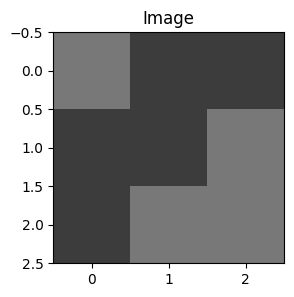

In [25]:
import numpy as np

A = np.array([[120, 60, 60],
              [60, 60, 120],
              [60, 120, 120]]).astype(np.uint8)

cv2_imshow(A, figsize=(3,3))

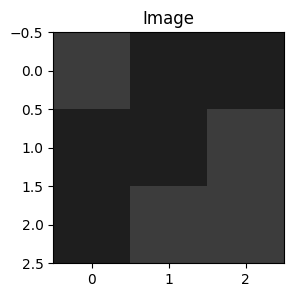

In [29]:
import numpy as np

dark = (1/2*A).astype(np.uint8)

cv2_imshow(dark, figsize=(3,3))

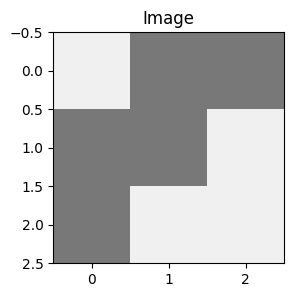

In [30]:
import numpy as np

bright = (2*A).astype(np.uint8)

cv2_imshow(bright, figsize=(3,3))

### ***Brightness(명도)와 Contrast(대비)함께 조정하기***
- 아래 2가지 경우를 비교해보겠습니다
    - k = 2, b = 0
    - k = 0, b = 100
- 그리고 그림판와 같은 도구에서도 명도와 대비를 조정해봅시다


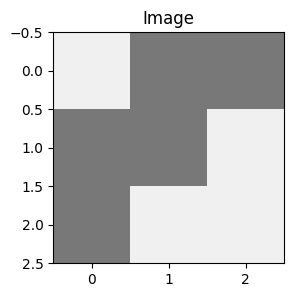

In [ ]:
import cv2
import numpy as np

A = np.array([[120, 60, 60],
              [60, 60, 120],
              [60, 120, 120]]).astype(np.uint8)

# 위 A 행렬을 확대해서 그림파일로 저장한 것입니다
# 이것을 그림판과 같은 도구에서 열고 명도와 대비를 조정해봅시다
cv2.imwrite('A.png', np.repeat(np.repeat(A, 10, axis=0), 10, axis=1))

k = 2   # contrast
b = 0    # brightness

out = k * A.astype(np.float64) + b
out = np.clip(out, 0, 255).astype(np.uint8)

cv2_imshow(out, figsize=(3,3))

## ***이미지 교차변환(Blending)***
- 테스트를 위해 샘플 이미지를 다운로드 받겠습니다

In [41]:
! wget https://raw.githubusercontent.com/opencv/opencv/4.x/samples/data/LinuxLogo.jpg
! wget https://raw.githubusercontent.com/opencv/opencv/4.x/samples/data/WindowsLogo.jpg

--2026-05-09 21:27:15--  https://raw.githubusercontent.com/opencv/opencv/4.x/samples/data/LinuxLogo.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6968 (6.8K) [image/jpeg]
Saving to: ‘LinuxLogo.jpg’

LinuxLogo.jpg       100%[===================>]   6.80K  --.-KB/s    in 0s      

2026-05-09 21:27:15 (54.2 MB/s) - ‘LinuxLogo.jpg’ saved [6968/6968]

--2026-05-09 21:27:16--  https://raw.githubusercontent.com/opencv/opencv/4.x/samples/data/WindowsLogo.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11318 (11K) [image/jpeg]
Sa

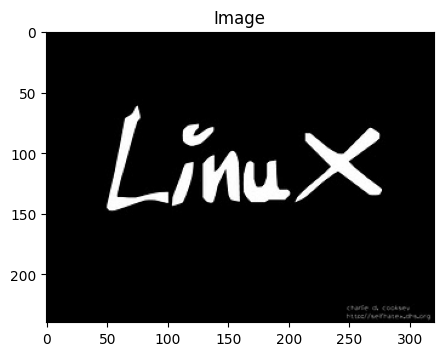

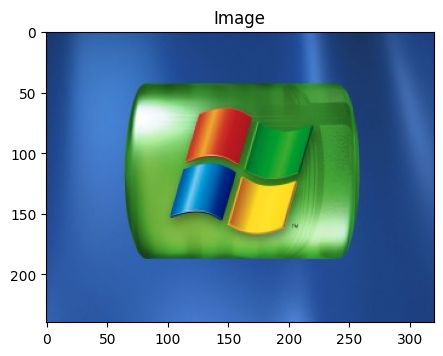

In [42]:
import cv2

src1 = cv2.imread('LinuxLogo.jpg')
src2 = cv2.imread('WindowsLogo.jpg')

cv2_imshow(src1)
cv2_imshow(src2)

#### ***이미지 내용 확인***
- 리눅스 로고는 0으로 채워진 검정색 위에 흰색 글씨입니다

In [43]:
src1

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [3, 3, 3],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [3, 3, 3],
        [0, 0, 0],
        [0, 0, 0]]], shape=(240, 320, 3), dtype=uint8)

In [ ]:
src2

#### ***이미지 2개 더하기***
- 단순히 2개의 이미지에 + 연산을 하는것만으로도 blending 효과를 볼 수 있습니다
- 단, 여기서도 overflow와 underflow가 발생하기 때문에 clip을 적용해 주어야 합니다
- We can simply tell image-blending is just adding two images but in this case clipping is required to prevent overflow and underflow

In [44]:
src1 + src2

array([[[111,  57,  27],
        [112,  58,  28],
        [112,  58,  28],
        ...,
        [128,  63,  32],
        [127,  62,  31],
        [127,  62,  31]],

       [[111,  57,  27],
        [112,  58,  28],
        [112,  58,  28],
        ...,
        [128,  63,  32],
        [127,  62,  31],
        [127,  62,  31]],

       [[112,  58,  28],
        [112,  58,  28],
        [112,  58,  28],
        ...,
        [128,  63,  32],
        [128,  63,  32],
        [128,  63,  32]],

       ...,

       [[173,  98,  52],
        [173,  98,  52],
        [173,  98,  52],
        ...,
        [125,  64,  30],
        [125,  64,  30],
        [125,  64,  30]],

       [[173,  98,  52],
        [173,  98,  52],
        [173,  98,  52],
        ...,
        [126,  65,  31],
        [129,  68,  34],
        [126,  65,  31]],

       [[173,  98,  52],
        [173,  98,  52],
        [174,  99,  53],
        ...,
        [129,  68,  34],
        [126,  65,  31],
        [126,  65,  31]]

#### ***아래와 같은 결과가 나온 이유***
- 성분이 255인(완전한 흰색)인 픽셀에서는 modulo operation으로 동작하여 \+ 연산을 하기 이전과 같은 값이 됩니다

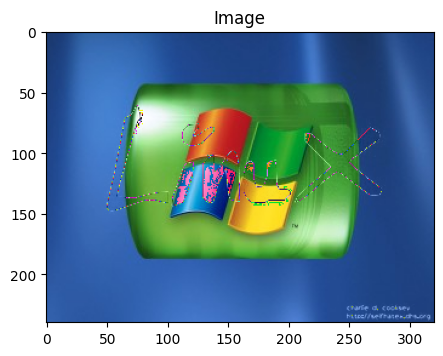

In [45]:
cv2_imshow(src1 + src2)

#### ***픽셀값의 상한, 하한 clip 적용***
- \+ 결과 255가 넘는 픽셀에서 modulo operation으로 동작하지 않고 최대 농도인 255가 유지됩니다

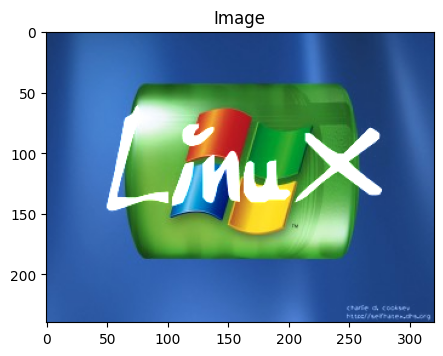

In [46]:
import numpy as np
from matplotlib import pyplot as plt

blended_img = np.clip(src1.astype(int)+src2.astype(int), 0 , 255).astype(np.uint8)

cv2_imshow(blended_img)

### ***weighted blending***
- 두 이미지의 blending 비율을 다르게 할 수 있습니다
- opencv-python에서 제공하는 addweighted()를 사용한 방법과 numpy를 이용한 방법이 있습니다

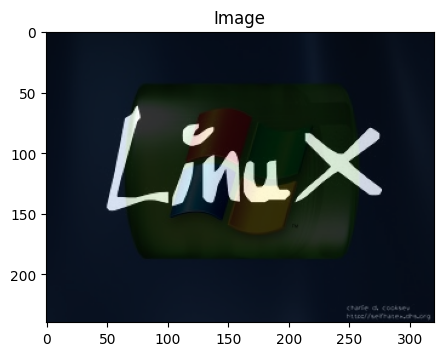

In [49]:
alpha = 0.8
beta = (1.0 - alpha)
#blended_img = cv2.addWeighted(src1, alpha, src2, beta, 0.0)
blended_img = (alpha*(src1)+beta*(src2)).astype(np.uint8)

cv2_imshow(blended_img)

### ***컬러 이미지를 흑백 이미지로 만드는 방법***
- 간단한 방법은 R, G, B 채널 성분을 3분의 1씩 더하는 것입니다
- 먼저 원본 이미지의 채널 성분들을 확인해봅니다

In [53]:
color = cv2.imread('WindowsLogo.jpg')

color

array([[[111,  57,  27],
        [112,  58,  28],
        [112,  58,  28],
        ...,
        [128,  63,  32],
        [127,  62,  31],
        [127,  62,  31]],

       [[111,  57,  27],
        [112,  58,  28],
        [112,  58,  28],
        ...,
        [128,  63,  32],
        [127,  62,  31],
        [127,  62,  31]],

       [[112,  58,  28],
        [112,  58,  28],
        [112,  58,  28],
        ...,
        [128,  63,  32],
        [128,  63,  32],
        [128,  63,  32]],

       ...,

       [[173,  98,  52],
        [173,  98,  52],
        [173,  98,  52],
        ...,
        [125,  64,  30],
        [125,  64,  30],
        [125,  64,  30]],

       [[173,  98,  52],
        [173,  98,  52],
        [173,  98,  52],
        ...,
        [126,  65,  31],
        [126,  65,  31],
        [126,  65,  31]],

       [[173,  98,  52],
        [173,  98,  52],
        [174,  99,  53],
        ...,
        [126,  65,  31],
        [126,  65,  31],
        [126,  65,  31]]

#### ***Blue채널 색상 정보***

In [54]:
color[ :, :, 0]

array([[111, 112, 112, ..., 128, 127, 127],
       [111, 112, 112, ..., 128, 127, 127],
       [112, 112, 112, ..., 128, 128, 128],
       ...,
       [173, 173, 173, ..., 125, 125, 125],
       [173, 173, 173, ..., 126, 126, 126],
       [173, 173, 174, ..., 126, 126, 126]], shape=(240, 320), dtype=uint8)

#### ***Green채널 색상 정보***

In [51]:
color[ :, :, 1]

array([[57, 58, 58, ..., 63, 62, 62],
       [57, 58, 58, ..., 63, 62, 62],
       [58, 58, 58, ..., 63, 63, 63],
       ...,
       [98, 98, 98, ..., 64, 64, 64],
       [98, 98, 98, ..., 65, 65, 65],
       [98, 98, 99, ..., 65, 65, 65]], shape=(240, 320), dtype=uint8)

#### ***Red채널 색상 정보***

In [52]:
color[ :, :, 2]

array([[27, 28, 28, ..., 32, 31, 31],
       [27, 28, 28, ..., 32, 31, 31],
       [28, 28, 28, ..., 32, 32, 32],
       ...,
       [52, 52, 52, ..., 30, 30, 30],
       [52, 52, 52, ..., 31, 31, 31],
       [52, 52, 53, ..., 31, 31, 31]], shape=(240, 320), dtype=uint8)

#### ***각채널 색상 3분의 1씩 합치기***

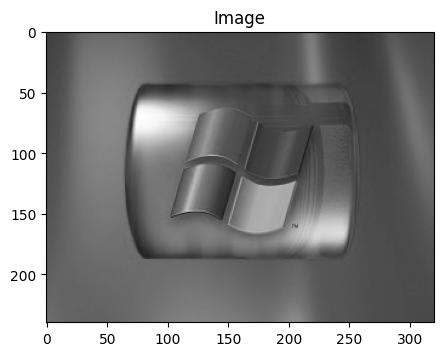

[[ 65  65  65 ...  74  73  73]
 [ 65  65  65 ...  74  73  73]
 [ 65  65  65 ...  74  74  74]
 ...
 [107 107 107 ...  73  73  73]
 [107 107 107 ...  74  74  74]
 [107 107 108 ...  74  74  74]]


In [59]:
gray = (1/3*color[ :, :, 0] + 1/3*color[ :, :, 1] + 1/3*color[ :, :, 2]).astype(np.uint8)


cv2_imshow(gray)
print(gray)

#### ***OpenCV함수를 이용한 흑백 이미지 변환***
- 위의 값과 다릅니다
- https://docs.opencv.org/3.4/de/d25/imgproc_color_conversions.html를 따르면 변환식은 아래와 같습니다

    $Y = 0.299R + 0.587G + 0.114B$

- 이것은 사람의 시각에서 가중치를 적용한 것입니다
  - 사람 눈이 밝기를 느끼는 정도(민감도)를 반영해서 가중치가 적용된 것입니다

In [58]:
color = cv2.imread('WindowsLogo.jpg')

cv2.cvtColor(color, cv2.COLOR_BGR2GRAY)

array([[54, 55, 55, ..., 61, 60, 60],
       [54, 55, 55, ..., 61, 60, 60],
       [55, 55, 55, ..., 61, 61, 61],
       ...,
       [93, 93, 93, ..., 61, 61, 61],
       [93, 93, 93, ..., 62, 62, 62],
       [93, 93, 94, ..., 62, 62, 62]], shape=(240, 320), dtype=uint8)

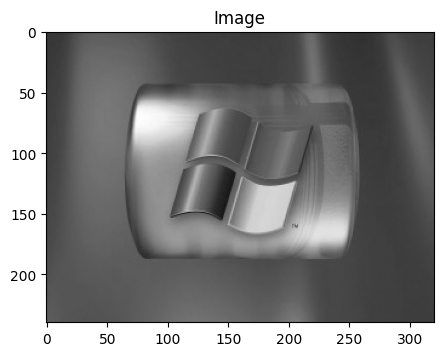

[[54 55 55 ... 61 60 60]
 [54 55 55 ... 61 60 60]
 [55 55 55 ... 61 61 61]
 ...
 [92 92 92 ... 60 60 60]
 [92 92 92 ... 61 61 61]
 [92 92 93 ... 61 61 61]]


In [60]:
gray = (0.114*color[ :, :, 0] + 0.587*color[ :, :, 1] + 0.299*color[ :, :, 2]).astype(np.uint8)


cv2_imshow(gray)
print(gray)